# Predicting student performance (`score`)

**Task:** predict `score` for the 79 students in `test.rds`; metric = mean squared error (MSE).

**Plan**
1. Explore the training data (distribution, linearity, categorical effects)
2. Feature engineering / transformation
3. Compare several models with **nested cross-validation** (tuning inside, honest error outside)
4. Diagnose fit and over-fitting (train vs CV error, adjusted R², validation & learning curves, residuals)
5. Plot fitted curves against the data, pick the best model, write `predictions.rds`

In [148]:
import warnings, subprocess, shutil, glob, time
import numpy as np, pandas as pd
import matplotlib.pyplot as plt, seaborn as sns
import pyreadr
from scipy import stats

from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer, make_column_selector
from sklearn.preprocessing import OneHotEncoder, StandardScaler, FunctionTransformer
from sklearn.linear_model import LinearRegression, Ridge, Lasso, ElasticNet, lasso_path
from sklearn.neighbors import KNeighborsRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.dummy import DummyRegressor
from sklearn.model_selection import (GridSearchCV, KFold, RepeatedKFold, cross_validate,
                                     cross_val_predict, validation_curve, learning_curve, train_test_split)
from sklearn.metrics import mean_squared_error, r2_score

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams["figure.dpi"] = 100
SEED = 42

train = pyreadr.read_r("train.rds")[None]
test = pyreadr.read_r("test.rds")[None]
X_raw = train.drop(columns="score")
y = train["score"].to_numpy()
n = len(train)
print(train.shape, test.shape, "missing values:", int(train.isna().sum().sum()), int(test.isna().sum().sum()))
train.head()

(316, 31) (79, 30) missing values: 0 0


,school,sex,age,address,famsize,Pstatus,Medu,Fedu,Mjob,Fjob,...,internet,romantic,famrel,freetime,goout,Dalc,Walc,health,absences,score
0,GP,F,18.0,U,GT3,T,3.0,2.0,other,services,...,yes,yes,5.0,4.0,3.0,2.0,3.0,1.0,7.0,0.648402
1,GP,F,17.0,U,GT3,T,3.0,4.0,services,other,...,yes,no,4.0,4.0,5.0,1.0,3.0,5.0,16.0,1.169019
2,GP,M,17.0,U,GT3,T,2.0,3.0,other,other,...,yes,no,5.0,2.0,2.0,1.0,1.0,2.0,4.0,0.384039
3,GP,M,18.0,R,GT3,T,4.0,3.0,teacher,services,...,yes,yes,5.0,3.0,2.0,1.0,2.0,4.0,9.0,1.207493
4,GP,F,16.0,U,GT3,T,1.0,3.0,at_home,services,...,yes,yes,4.0,3.0,5.0,1.0,1.0,3.0,0.0,-1.215206


## 1. Exploratory data analysis

Variance of score (= MSE of always predicting the mean): 0.97


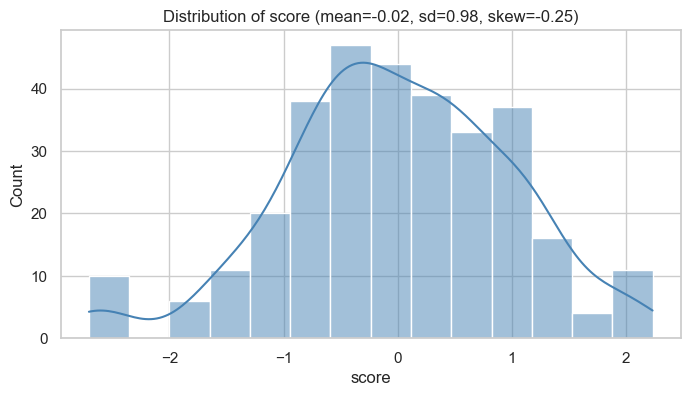

In [149]:
fig, ax = plt.subplots(figsize=(8, 4))
sns.histplot(train["score"], kde=True, ax=ax, color="steelblue")
ax.set_title(f"Distribution of score (mean={y.mean():.2f}, sd={y.std():.2f}, skew={stats.skew(y):.2f})")
print("Variance of score (= MSE of always predicting the mean):", round(y.var(), 3))

`score` looks standardised and roughly normal, so no target transformation is needed.
The MSE of the "predict the mean" baseline is about the variance of `score` (~0.97). Any useful model must beat that.

### Linearity check: numeric predictors (red = LOWESS smoother; a straight red line means a linear relation)

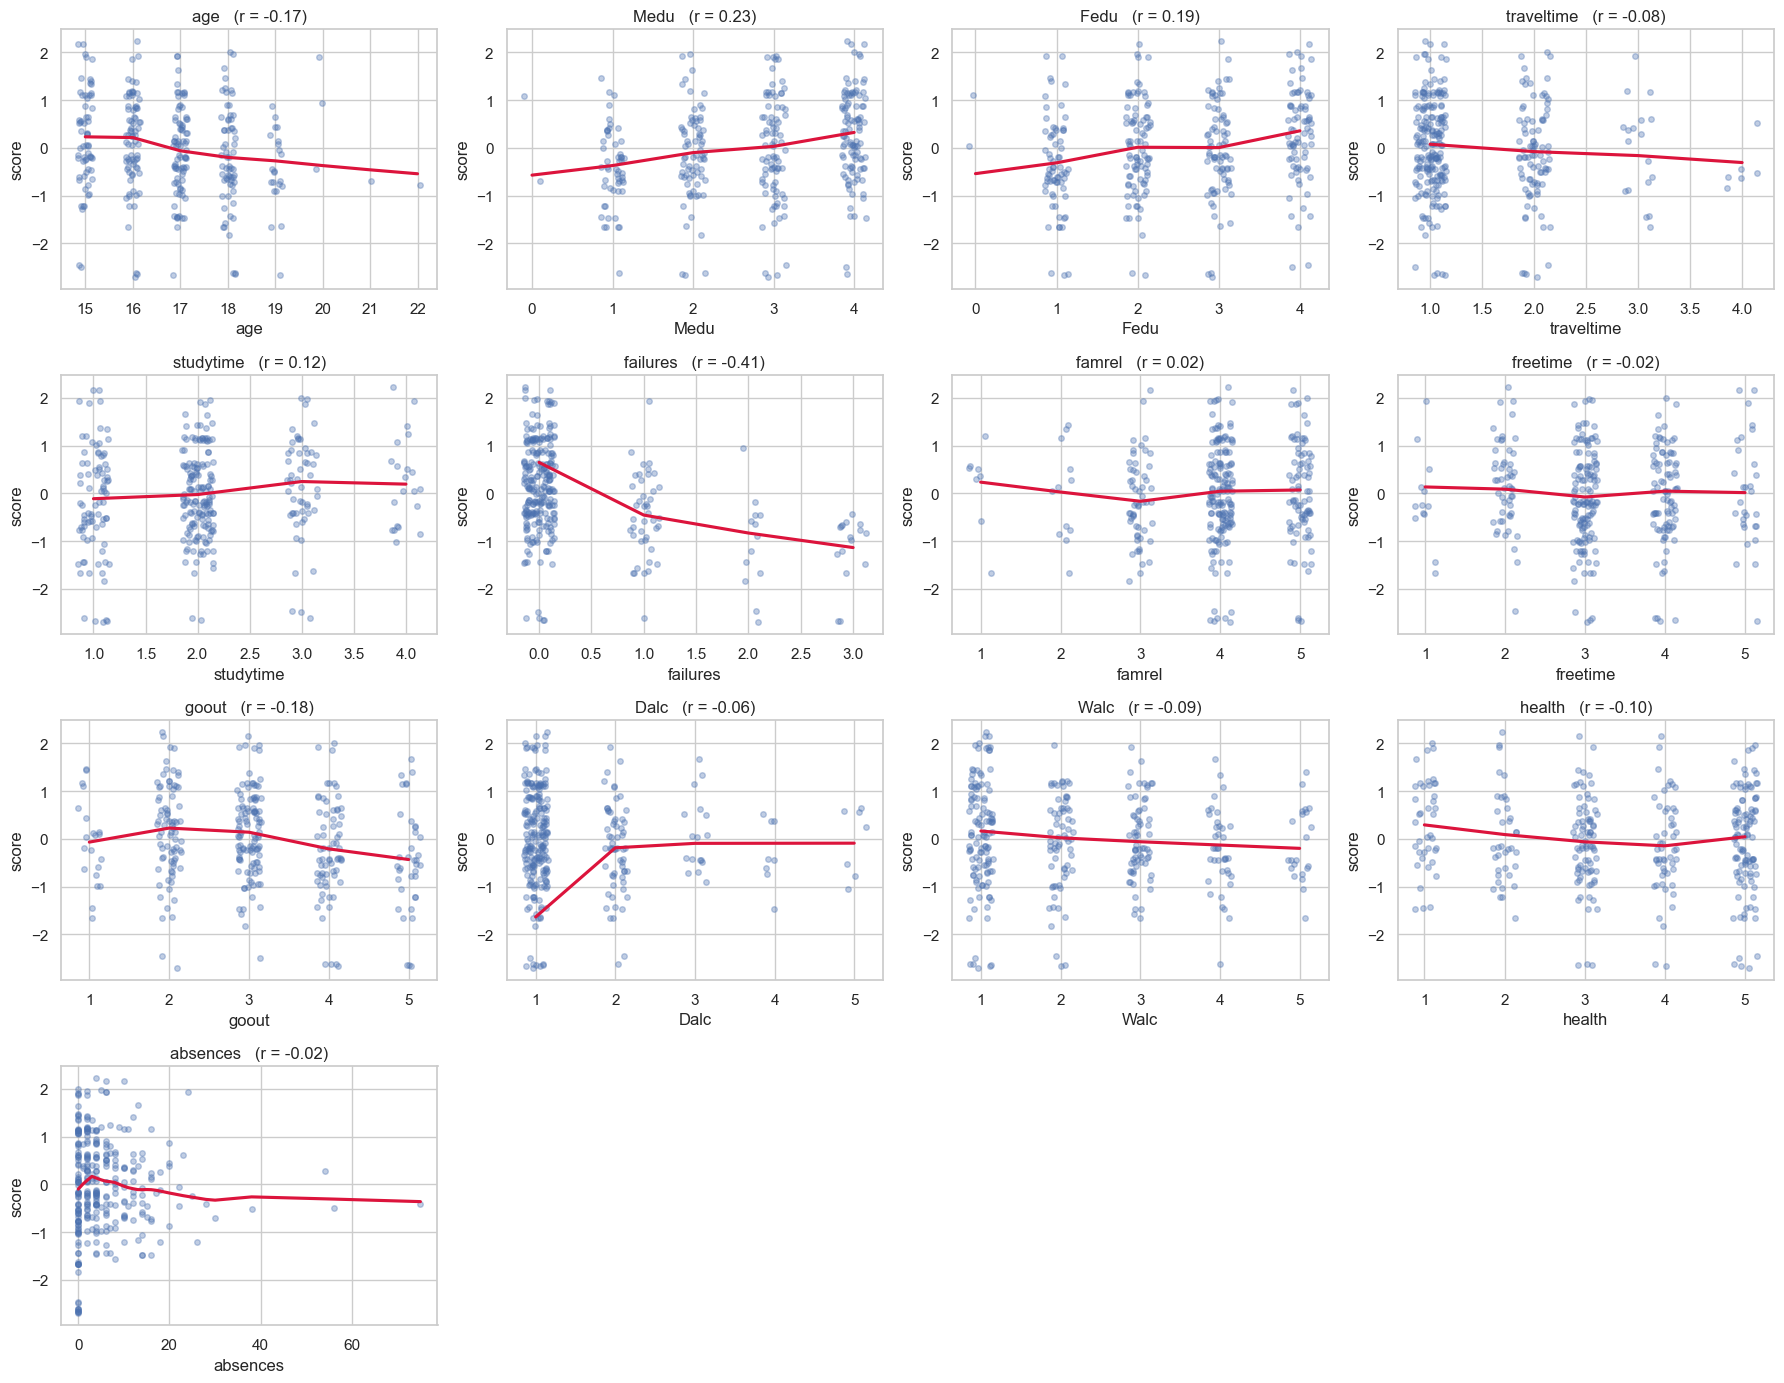

In [150]:
num_cols = X_raw.select_dtypes("number").columns.tolist()
fig, axes = plt.subplots(4, 4, figsize=(18, 14)); axes = axes.ravel()
for ax, c in zip(axes, num_cols):
    sns.regplot(data=train, x=c, y="score", lowess=True, x_jitter=0.15 if train[c].nunique() <= 20 else 0,
                scatter_kws=dict(alpha=.35, s=16), line_kws=dict(color="crimson"), ax=ax)
    ax.set_title(f"{c}   (r = {train[c].corr(train['score']):.2f})")
for ax in axes[len(num_cols):]: ax.axis("off")
plt.tight_layout(); plt.show()

### Categorical predictors

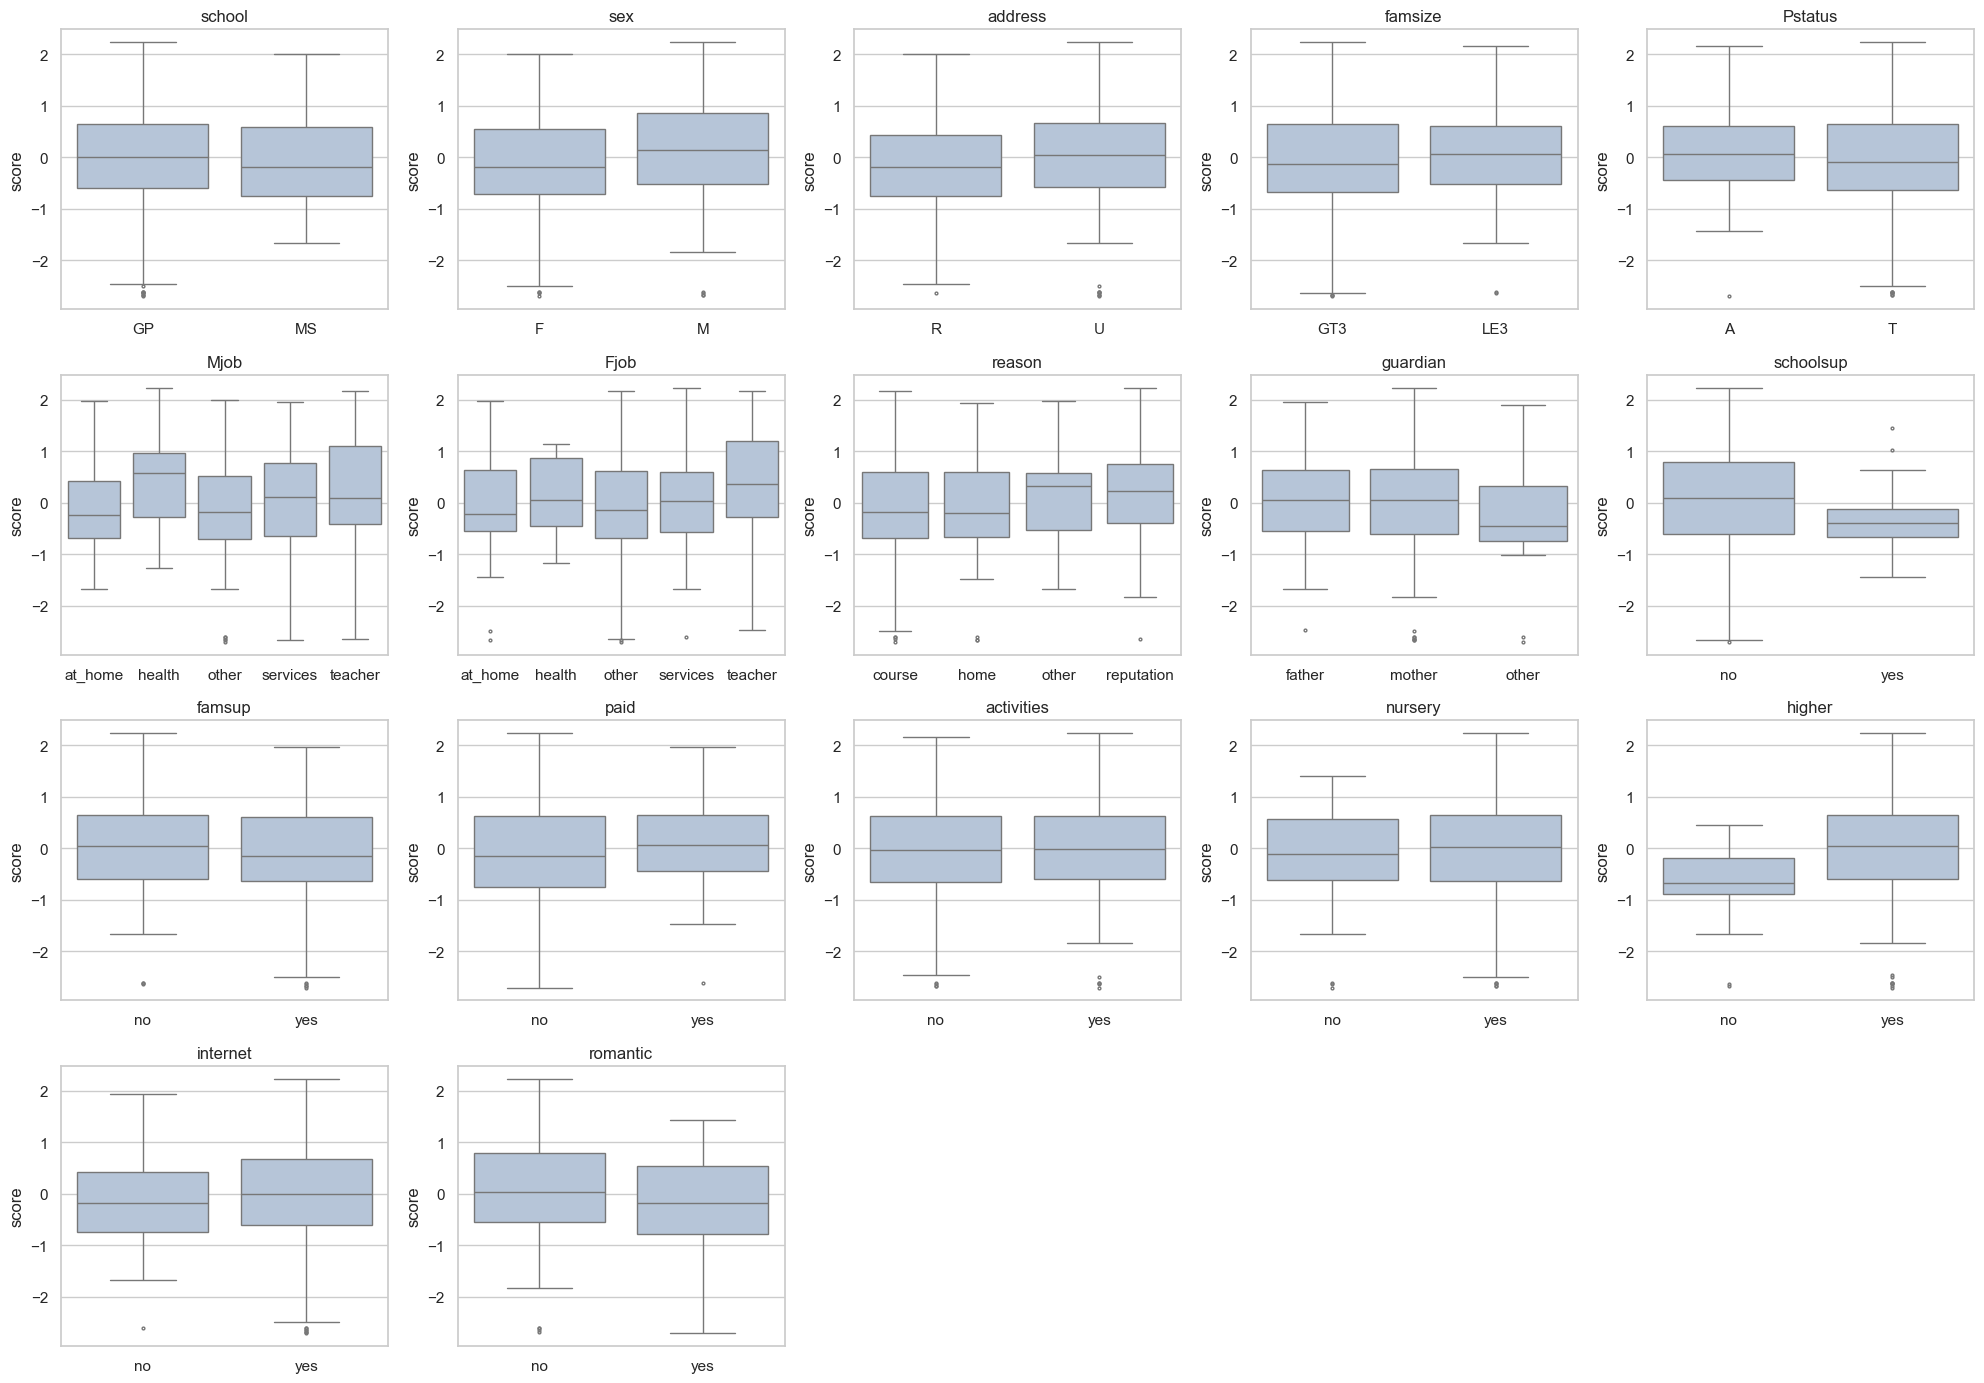

In [151]:
cat_cols = X_raw.select_dtypes("category").columns.tolist()
fig, axes = plt.subplots(4, 5, figsize=(20, 14)); axes = axes.ravel()
for ax, c in zip(axes, cat_cols):
    sns.boxplot(data=train, x=c, y="score", ax=ax, color="lightsteelblue", fliersize=2)
    ax.set_title(c); ax.set_xlabel("")
for ax in axes[len(cat_cols):]: ax.axis("off")
plt.tight_layout(); plt.show()

### Which variables matter on their own? (univariate R² for numeric, η² for categorical) + correlation heatmap

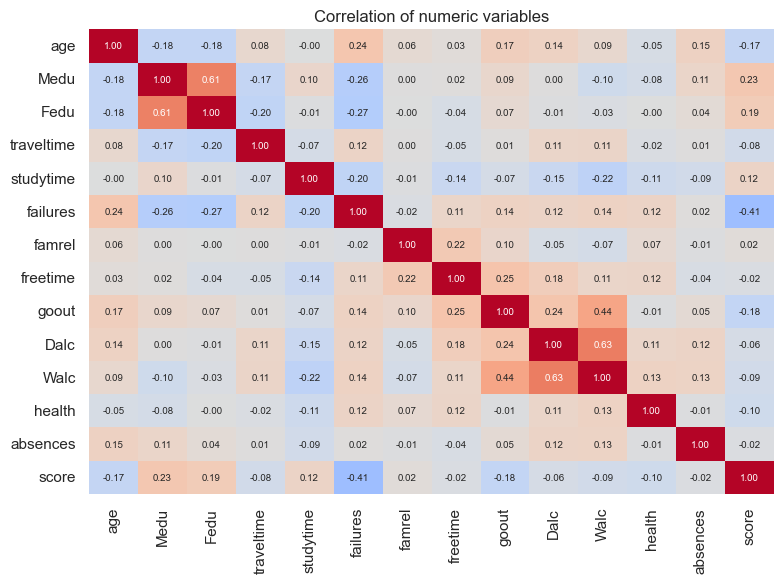

In [152]:
plt.figure(figsize=(8, 6))
sns.heatmap(train[num_cols + ["score"]].corr(), annot=True, fmt=".2f", cmap="coolwarm", center=0,
            annot_kws=dict(size=7), cbar=False)
plt.title("Correlation of numeric variables")
plt.tight_layout(); plt.show()

**What the plots say**
* Relationships are mostly weak and roughly linear. The strongest single signals are `failures` (clearly negative), `Medu`/`Fedu` and `Mjob` (positive), `goout` (negative), `higher`, `schoolsup`, `age`.
* `absences` is heavily right-skewed (many zeros, a few very large values) and shows no clear linear pattern, so it needs a transformation.
* The predictors are ordinal (1–5) with few levels, so linear trends are plausible but not guaranteed. The tree-based models test that.
* Because the signal is weak, expect a modest R². A large gap between train and CV error would be the main risk, which favours regularised models.

## 2. Feature engineering

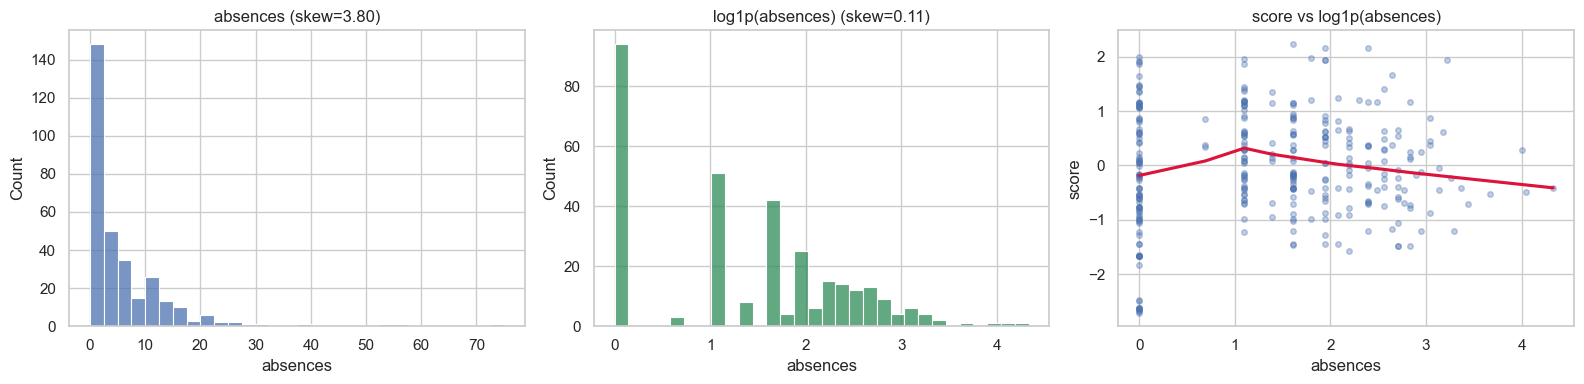

In [153]:
fig, ax = plt.subplots(1, 3, figsize=(16, 4))
sns.histplot(train["absences"], bins=30, ax=ax[0]); ax[0].set_title(f"absences (skew={stats.skew(train['absences']):.2f})")
la = np.log1p(train["absences"])
sns.histplot(la, bins=30, ax=ax[1], color="seagreen"); ax[1].set_title(f"log1p(absences) (skew={stats.skew(la):.2f})")
sns.regplot(x=la, y=train["score"], lowess=True, scatter_kws=dict(alpha=.35, s=16), line_kws=dict(color="crimson"), ax=ax[2])
ax[2].set_title("score vs log1p(absences)")
plt.tight_layout(); plt.show()

Feature engineering applied inside every model pipeline (so that no information leaks between CV folds):

| Step | Why |
|---|---|
| `absences` → `log1p(absences)` and a `no_absences` flag | removes the extreme skew, and separates "never absent" from the rest |
| `had_failure` = `failures > 0` | failures is mostly 0 with a few large values, so this adds a threshold effect |
| `Medu × Fedu` | allows an interaction between mother's and father's education |
| One-hot encoding of categoricals (binary → 1 dummy column; variables with 3+ levels → one column per level; unseen levels in new data are ignored) | numeric input for the models |
| Standardisation of every column | required for a fair Ridge/Lasso penalty and for KNN distances |

In [154]:
def engineer(df):
    d = df.copy()
    d["log_absences"] = np.log1p(d["absences"])
    d["no_absences"] = (d["absences"] == 0).astype(float)
    d["had_failure"] = (d["failures"] > 0).astype(float)
    d["Medu_x_Fedu"] = d["Medu"] * d["Fedu"]
    return d.drop(columns="absences")

def no_fe(df):
    return df

def make_pre(fe=engineer):
    return Pipeline([
        ("fe", FunctionTransformer(fe)),
        ("ct", ColumnTransformer(
            [("cat", OneHotEncoder(drop="if_binary", handle_unknown="ignore", sparse_output=False),
              make_column_selector(dtype_include=["category", "object"]))],
            remainder="passthrough", verbose_feature_names_out=False)),
        ("sc", StandardScaler()),
    ])

pre_demo = make_pre().fit(X_raw)
feat_names = pre_demo.named_steps["ct"].get_feature_names_out()
print(len(feat_names), "model features after encoding:")
print(list(feat_names))

46 model features after encoding:
['school_MS', 'sex_M', 'address_U', 'famsize_LE3', 'Pstatus_T', 'Mjob_at_home', 'Mjob_health', 'Mjob_other', 'Mjob_services', 'Mjob_teacher', 'Fjob_at_home', 'Fjob_health', 'Fjob_other', 'Fjob_services', 'Fjob_teacher', 'reason_course', 'reason_home', 'reason_other', 'reason_reputation', 'guardian_father', 'guardian_mother', 'guardian_other', 'schoolsup_yes', 'famsup_yes', 'paid_yes', 'activities_yes', 'nursery_yes', 'higher_yes', 'internet_yes', 'romantic_yes', 'age', 'Medu', 'Fedu', 'traveltime', 'studytime', 'failures', 'famrel', 'freetime', 'goout', 'Dalc', 'Walc', 'health', 'log_absences', 'no_absences', 'had_failure', 'Medu_x_Fedu']


## 3. Models and tuning

Candidates (all tuned by cross-validation on the training data only):

* **Mean baseline**, **OLS**, **Ridge**, **Lasso**, **Elastic Net** (linear)
* **KNN**, **Regression tree** (simple non-linear)
* **Random forest**, **Gradient boosting** (flexible non-linear)
* **Hierarchical regression** (three theme-based OLS sub-models -- academic, family, lifestyle -- feeding a master OLS; ported from `Hier_Model.R`; no hyper-parameters to tune)

**Validation strategy: nested cross-validation.** 

The *inner* 5-fold CV chooses the hyper-parameters
(α, k, depth, …); the *outer* 5-fold × 3-repeat CV measures the error of the whole procedure on data never used
for tuning. That gives an honest estimate of the MSE we should expect on the test set. Every model sees the same outer folds, so the comparison is paired and fair.

#### Define hierarchical model

**Steps and the logic behind each**

1. **Declare three column blocks** (`ACADEMIC_COLS`, `FAMILY_COLS`, `LIFESTYLE_COLS`) using the column names that `engineer()` produces (`log_absences`, `no_absences`, `had_failure`, `Medu_x_Fedu`).
2. **`_block_pipe` builds one sub-model:** one-hot encode the block's categorical columns, pass the numeric ones through, then fit OLS.
3. **`fit` runs the three stages in order:** 
   (a) fit one OLS per block to `score`; 
   (b) take each block's fitted values as that block's *proxy*, one number per student; 
   (c) fit a master OLS of `score` on the three proxies.
4. **`predict` pushes new rows through the stored sub-models, then through the master model.**

In [155]:
from sklearn.base import BaseEstimator, RegressorMixin

# Column blocks, using the names produced by engineer() in section 2
ACADEMIC_COLS = ["school", "reason", "studytime", "failures", "had_failure",
                 "schoolsup", "paid", "higher", "log_absences", "no_absences", "traveltime"]
FAMILY_COLS = ["Medu", "Fedu", "Medu_x_Fedu", "guardian", "Mjob", "Fjob",
               "famsize", "Pstatus", "famrel", "nursery"]
LIFESTYLE_COLS = ["age", "sex", "address", "health", "romantic", "activities",
                  "internet", "freetime", "goout", "Dalc", "Walc"]


class HierarchicalRegressor(RegressorMixin, BaseEstimator):
    """Academic / family / lifestyle sub-models -> proxies -> master OLS."""

    def __init__(self, academic_cols, family_cols, lifestyle_cols):
        self.academic_cols = academic_cols
        self.family_cols = family_cols
        self.lifestyle_cols = lifestyle_cols

    def _block_pipe(self, cols, X):
        cat_cols = [c for c in cols if not pd.api.types.is_numeric_dtype(X[c])]
        ct = ColumnTransformer(
            [("cat", OneHotEncoder(drop="if_binary", handle_unknown="ignore", sparse_output=False), cat_cols)],
            remainder="passthrough")
        return Pipeline([("ct", ct), ("lm", LinearRegression())])

    def fit(self, X, y):
        X = pd.DataFrame(X).reset_index(drop=True)
        y = np.asarray(y)
        self.blocks_ = {"academic": self.academic_cols, "family": self.family_cols,
                        "lifestyle": self.lifestyle_cols}
        self.sub_pipes_ = {}
        for name, cols in self.blocks_.items():                     # stage 1: one OLS per block
            self.sub_pipes_[name] = self._block_pipe(cols, X).fit(X[cols], y)
        self.master_ = LinearRegression().fit(self._proxies(X), y)  # stage 2: master OLS on the proxies
        return self

    def _proxies(self, X):
        # one column per block (its fitted values), always in the same order (academic, family, lifestyle)
        return np.column_stack([self.sub_pipes_[name].predict(X[cols])
                                for name, cols in self.blocks_.items()])

    def predict(self, X):
        X = pd.DataFrame(X).reset_index(drop=True)
        return self.master_.predict(self._proxies(X))

#### Model registry and nested-CV objects

Defines all candidate models, tuning grids, CV splitters, and the tuned() helper.

**Steps and the logic behind each**

1. **`pipe()`** builds the pipeline for a model. For `HierarchicalRegressor` it applies only `engineer`; every other model still goes through the shared `make_pre()` (engineer, one-hot, standardise).
2. **`MODELS`** maps each name to `(estimator, grid)`. `"Hierarchical"` gets an empty grid.
3. **`inner_cv` and `outer_cv`** are the tuning and evaluation splitters.

In [156]:
def pipe(model, fe=engineer):
    if isinstance(model, HierarchicalRegressor):
        return Pipeline([("fe", FunctionTransformer(fe)), ("m", model)])
    return Pipeline([("pre", make_pre(fe)), ("m", model)])

BASE = "Mean (baseline)"
MODELS = {
    BASE: (DummyRegressor(), {}),
    "OLS": (LinearRegression(), {}),
    "Ridge": (Ridge(), {"m__alpha": np.logspace(-1, 3, 30)}),
    "Lasso": (Lasso(max_iter=50000), {"m__alpha": np.logspace(-3, -0.3, 30)}),
    "Elastic Net": (ElasticNet(max_iter=50000), {"m__alpha": np.logspace(-3, -0.3, 15), "m__l1_ratio": [.2, .5, .8]}),
    "KNN": (KNeighborsRegressor(), {"m__n_neighbors": [5, 10, 15, 20, 30, 40, 60], "m__weights": ["uniform", "distance"]}),
    "Tree": (DecisionTreeRegressor(random_state=SEED), {"m__max_depth": [2, 3, 4, 5], "m__min_samples_leaf": [5, 10, 20]}),
    "Random Forest": (RandomForestRegressor(n_estimators=300, random_state=SEED),
                      {"m__max_features": [0.2, 0.4], "m__min_samples_leaf": [3, 8]}),
    "Gradient Boosting": (GradientBoostingRegressor(subsample=0.7, random_state=SEED),
                          {"m__learning_rate": [0.01, 0.03], "m__max_depth": [1, 2], "m__n_estimators": [100, 300]}),
    "Hierarchical": (HierarchicalRegressor(ACADEMIC_COLS, FAMILY_COLS, LIFESTYLE_COLS), {}),
}
inner_cv = KFold(5, shuffle=True, random_state=SEED)
outer_cv = RepeatedKFold(n_splits=5, n_repeats=3, random_state=SEED)

def tuned(name, fe=engineer, cv=inner_cv):
    model, grid = MODELS[name]
    return GridSearchCV(pipe(model, fe), grid, cv=cv, scoring="neg_mean_squared_error", n_jobs=1)

mse = mean_squared_error

In [157]:
t0 = time.time()
nested = {}
for name in MODELS:
    nested[name] = cross_validate(tuned(name), X_raw, y, cv=outer_cv, n_jobs=-1, return_train_score=True,
                                  scoring={"mse": "neg_mean_squared_error", "r2": "r2"})
    print(f"{name:18s} done ({time.time() - t0:5.0f}s)  CV MSE = {-nested[name]['test_mse'].mean():.4f}")

rows = []
for name, r in nested.items():
    cv_mse, tr_mse = -r["test_mse"].mean(), -r["train_mse"].mean()
    rows.append(dict(model=name, CV_MSE=cv_mse,  train_MSE=tr_mse,
                     fold_sd_MSE=(-r["test_mse"]).std(), CV_R2=r["test_r2"].mean(),
                     overfit_ratio=cv_mse / tr_mse))
res = pd.DataFrame(rows).set_index("model").sort_values("CV_MSE")
res.round(4)

Mean (baseline)    done (    1s)  CV MSE = 0.9746
OLS                done (    1s)  CV MSE = 0.8529
Ridge              done (    6s)  CV MSE = 0.7849
Lasso              done (   11s)  CV MSE = 0.7870
Elastic Net        done (   19s)  CV MSE = 0.7859
KNN                done (   22s)  CV MSE = 0.8700
Tree               done (   24s)  CV MSE = 0.7909
Random Forest      done (   34s)  CV MSE = 0.7479
Gradient Boosting  done (   41s)  CV MSE = 0.7576
Hierarchical       done (   42s)  CV MSE = 0.8043


,CV_MSE,train_MSE,fold_sd_MSE,CV_R2,overfit_ratio
model,,,,,
Random Forest,0.7479,0.4010,0.1629,0.2248,1.8651
Gradient Boosting,0.7576,0.5655,0.1601,0.2144,1.3398
Ridge,0.7849,0.6485,0.1525,0.1830,1.2103
Elastic Net,0.7859,0.6727,0.1528,0.1826,1.1682
Lasso,0.7870,0.6780,0.1510,0.1810,1.1608
Tree,0.7909,0.7190,0.1651,0.1783,1.1001
Hierarchical,0.8043,0.6503,0.1764,0.1662,1.2367
OLS,0.8529,0.5955,0.1559,0.1079,1.4321
KNN,0.8700,0.1449,0.1585,0.0948,6.0054


### Model comparison chart (nested CV): error per fold and train-vs-CV gap (over-fitting check)

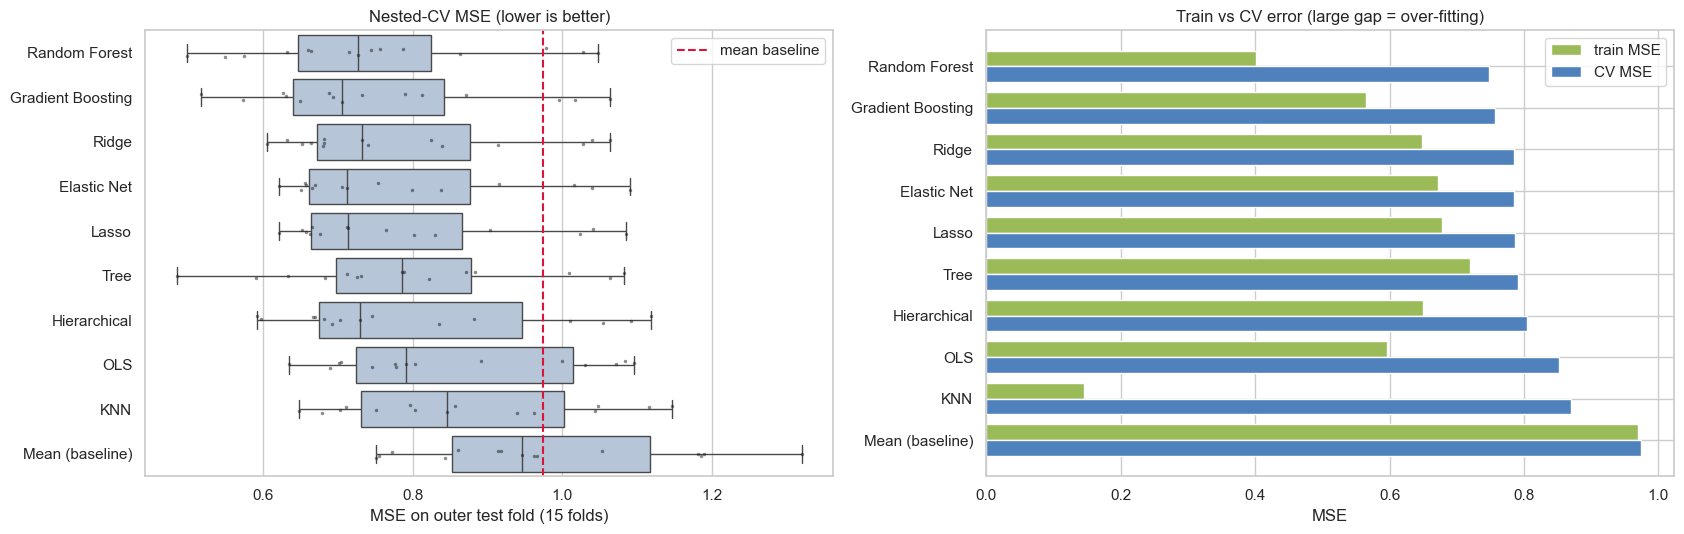

In [177]:
order = res.index.tolist()

fold_mse = pd.DataFrame({k: -nested[k]["test_mse"] for k in order})
fig, ax = plt.subplots(1, 2, figsize=(17, 5.5))
sns.boxplot(data=fold_mse, orient="h", ax=ax[0], color="lightsteelblue", fliersize=3)
sns.stripplot(data=fold_mse, orient="h", ax=ax[0], color="k", size=2.5, alpha=.5)
ax[0].axvline(res.loc[BASE, "CV_MSE"], color="crimson", ls="--", label="mean baseline")
ax[0].set_xlabel("MSE on outer test fold (15 folds)"); ax[0].set_title("Nested-CV MSE (lower is better)"); ax[0].legend()

w = 0.38; ypos = np.arange(len(order))
ax[1].barh(ypos - w/2, res["train_MSE"], w, label="train MSE", color="#9bbb59")
ax[1].barh(ypos + w/2, res["CV_MSE"], w, label="CV MSE", color="#4f81bd")
ax[1].set_yticks(ypos); ax[1].set_yticklabels(order); ax[1].invert_yaxis()
ax[1].set_xlabel("MSE"); ax[1].set_title("Train vs CV error (large gap = over-fitting)"); ax[1].legend()
plt.tight_layout(); plt.show()

In [159]:
cmp = {}
for name in ["Ridge", "Lasso", "Random Forest"]:
    for lab, fe in [("raw", no_fe), ("engineered", engineer)]:
        r = cross_validate(tuned(name, fe=fe), X_raw, y, cv=outer_cv, n_jobs=-1, scoring="neg_mean_squared_error")
        cmp[(name, lab)] = -r["test_score"].mean()
cmp = pd.Series(cmp).unstack()
cmp["improvement_%"] = 100 * (cmp["raw"] - cmp["engineered"]) / cmp["raw"]
cmp.round(4)

,engineered,raw,improvement_%
Lasso,0.7870,0.8151,3.4399
Random Forest,0.7479,0.7548,0.9139
Ridge,0.7849,0.8181,4.0629


### Hierarchical regression: feature-engineering scenarios and multicollinearity

The hierarchical model uses plain OLS at every stage, with no shrinkage, so collinear predictors inflate its coefficient variance (just as they do for plain OLS above). `Medu × Fedu` is built from `Medu` and `Fedu`, so it is a natural suspect. This section also tests a `Dalc + Walc` combination that is new here (it is not part of `engineer()`).

It does three things: (1) defines switches that turn each engineering step on and off, (2) checks multicollinearity before and after engineering, and (3) measures MSE, R² and adjusted R² of the hierarchical model under several feature sets. Everything is scored on the same `outer_cv` folds as the models above, so the numbers are directly comparable with the `res` table.

#### (a) Feature switches and scenario definitions

**What this block is for.** `build_engineered()` generalises `engineer()` into independent on/off switches and also returns the column lists for the three blocks, so any combination of engineering steps can be built with one call. `SCENARIOS` names the five combinations compared below.

**Steps and the logic behind each**

1. **Copy the input frame.**
   *Logic:* avoids modifying `X_raw` in place, which would leak engineered columns into other cells.
2. **Academic block:** use `log1p(absences)` or raw `absences`; optionally add a `no_absences` flag and a `had_failure` flag next to raw `failures`.
   *Logic:* `absences` is heavily right-skewed with many zeros, so `log1p` compresses the tail while keeping zeros defined, and the flag separates "never absent" from "sometimes absent". `failures` is mostly 0, so `failures > 0` adds a threshold effect that a straight line in `failures` cannot express.
3. **Family block:** optionally add `Medu_x_Fedu` next to `Medu` and `Fedu`.
   *Logic:* the product lets the effect of one parent's education depend on the other's.
4. **Lifestyle block:** optionally add `alc_total = Dalc + Walc` next to `Dalc` and `Walc`.
   *Logic:* weekday and weekend drinking are correlated, and one total is a simpler summary of overall alcohol use.
5. **Return the engineered frame and the three column lists.**
   *Logic:* each sub-model can then select just its own block.
6. **`SCENARIOS`:** the original features, each engineering step alone, then all steps together.
   *Logic:* changing one thing at a time isolates that step's effect, and the last scenario shows the combined effect. Scenario 5 is `engineer()` plus `alc_total`.

In [160]:
def build_engineered(df, log_absences=False, no_absences_flag=False, had_failure=False,
                     medu_fedu=False, alc_combo=False):
    d = df.copy()

    academic_cols = ["school", "reason", "studytime", "failures", "schoolsup", "paid", "higher", "traveltime"]
    if log_absences:
        d["log_absences"] = np.log1p(d["absences"])
        academic_cols.append("log_absences")
    else:
        academic_cols.append("absences")
    if no_absences_flag:
        d["no_absences"] = (d["absences"] == 0).astype(float)
        academic_cols.append("no_absences")
    if had_failure:
        d["had_failure"] = (d["failures"] > 0).astype(float)
        academic_cols.append("had_failure")

    family_cols = ["Medu", "Fedu", "guardian", "Mjob", "Fjob", "famsize", "Pstatus", "famrel", "nursery"]
    if medu_fedu:
        d["Medu_x_Fedu"] = d["Medu"] * d["Fedu"]
        family_cols.append("Medu_x_Fedu")

    lifestyle_cols = ["age", "sex", "address", "health", "romantic", "activities",
                      "internet", "freetime", "goout", "Dalc", "Walc"]
    if alc_combo:
        d["alc_total"] = d["Dalc"] + d["Walc"]
        lifestyle_cols.append("alc_total")

    return d, academic_cols, family_cols, lifestyle_cols


SCENARIOS = {
    "1. Original (no engineering)": dict(),
    "2. log1p(absences)":           dict(log_absences=True),
    "3. Dalc + Walc combo":         dict(alc_combo=True),
    "4. Medu x Fedu interaction":   dict(medu_fedu=True),
    "5. All features engineered":   dict(log_absences=True, no_absences_flag=True,
                                         had_failure=True, medu_fedu=True, alc_combo=True),
}

#### (b) Multicollinearity before feature engineering: variance inflation factors

**What this block is for.** Puts a number on how strongly each **raw numeric** predictor is explained by the other numeric predictors. `vif_table()` is reused after engineering in block (d), so both tables are computed identically.

**Steps and the logic behind each**

1. **Keep the numeric predictors only** (`numeric_before`).
   *Logic:* the dummy columns of a categorical variable are dependent by construction, which would swamp the diagnostic; the numeric columns are where engineered products and sums cause trouble.
2. **Add a constant column** (`add_constant`).
   *Logic:* each VIF comes from regressing one column on all the others *with an intercept*. Without it the fit is forced through the origin and every VIF is overstated.
3. **For every column, regress it on the others and compute VIF = 1 / (1 − R²).**
   *Logic:* R² says how much of that column the others explain. A VIF of 1 means no overlap, and a VIF above about 5 is the usual warning level because the variance of that coefficient is inflated by the same factor. An exact linear dependence gives R² = 1, so the VIF is infinite.
4. **Drop the constant, sort from largest to smallest and return the table.**
   *Logic:* the worst offenders come first.

In [161]:
# statsmodels: if missing run  %pip install statsmodels  (and add it to requirements.txt)
from statsmodels.stats.outliers_influence import variance_inflation_factor
from statsmodels.tools import add_constant


def vif_table(df, cols):
    X = add_constant(df[cols].astype(float))
    vif = [variance_inflation_factor(X.values, i) for i in range(X.shape[1])]
    return (pd.DataFrame({"feature": X.columns, "VIF": vif})
              .query("feature != 'const'").sort_values("VIF", ascending=False).reset_index(drop=True))


numeric_before = ["age", "Medu", "Fedu", "traveltime", "studytime", "failures",
                  "famrel", "freetime", "goout", "Dalc", "Walc", "health", "absences"]
vif_before = vif_table(train, numeric_before)
vif_before

,feature,VIF
0,Walc,2.146703
1,Medu,1.789436
2,Dalc,1.769676
3,Fedu,1.719347
4,goout,1.440119
5,failures,1.231015
6,freetime,1.197911
7,age,1.176302
8,studytime,1.133535
9,famrel,1.086060


#### (c) Correlation heatmap after feature engineering

**What this block is for.** Builds the fully engineered data set (scenario 5) and draws the same kind of correlation heatmap as in section 1, so the two can be compared side by side. This is the "after" picture.

**Steps and the logic behind each**

1. **Build the scenario-5 data set** with `build_engineered()` and attach `score`.
   *Logic:* scenario 5 switches on every engineering step, which is the most collinearity-prone case.
2. **List the engineered numeric columns** (`numeric_after`): raw `absences` is replaced by `log_absences` and `no_absences`, and `had_failure`, `Medu_x_Fedu` and `alc_total` are added.
   *Logic:* these are the columns a model would actually see after engineering.
3. **Draw the heatmap of pairwise correlations, including `score`.**
   *Logic:* pairwise correlation exposes the obvious redundancy. In this data `Medu_x_Fedu` correlates 0.85 with `Medu` and 0.90 with `Fedu`, `alc_total` correlates 0.86 with `Dalc` and 0.94 with `Walc`, `had_failure` 0.87 with `failures`, and `no_absences` −0.83 with `log_absences`. Pairwise correlation cannot show a dependence that involves three or more columns, which is why the VIF is computed next.

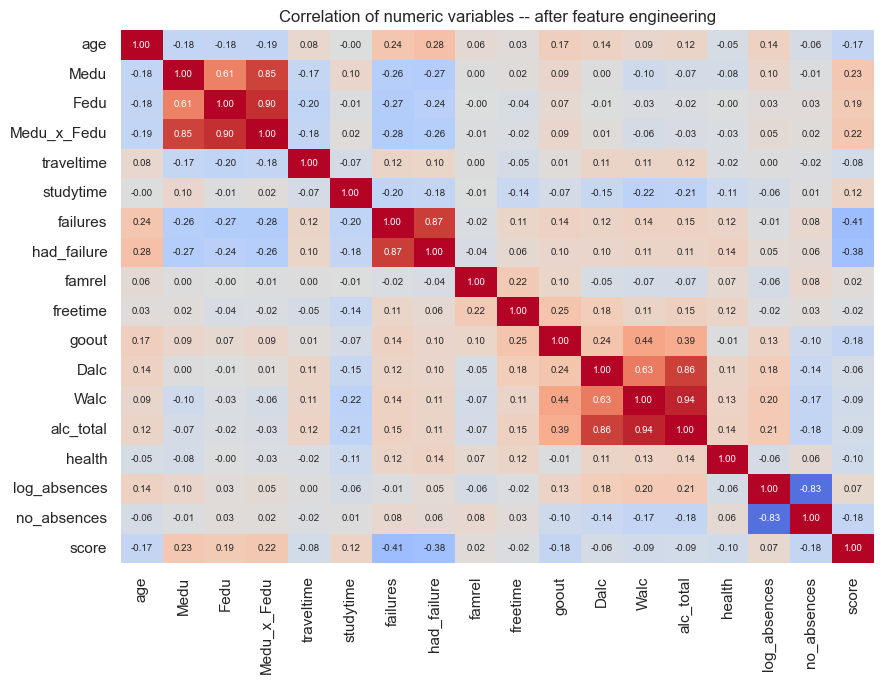

In [162]:
train_full_eng, academic_cols_full, family_cols_full, lifestyle_cols_full = build_engineered(
    X_raw, **SCENARIOS["5. All features engineered"])
train_full_eng["score"] = y

numeric_after = ["age", "Medu", "Fedu", "Medu_x_Fedu", "traveltime", "studytime", "failures", "had_failure",
                 "famrel", "freetime", "goout", "Dalc", "Walc", "alc_total", "health",
                 "log_absences", "no_absences"]

plt.figure(figsize=(9, 7))
sns.heatmap(train_full_eng[numeric_after + ["score"]].corr(), annot=True, fmt=".2f", cmap="coolwarm",
            center=0, annot_kws=dict(size=7), cbar=False)
plt.title("Correlation of numeric variables -- after feature engineering")
plt.tight_layout(); plt.show()

#### (f) Scoring function for any hierarchical feature set

**What this block is for.** `run_hier_cv()` scores one feature set (data frame plus the three column lists) and returns CV MSE, CV R², adjusted R² and the number of parameters. Every scenario below calls it, so all of them are evaluated identically.

**Steps and the logic behind each**

1. **Build a `HierarchicalRegressor` from the three column lists.**
   *Logic:* the scenarios differ only in which columns each block contains, so the model class is reused unchanged.
2. **Run `cross_validate` on `outer_cv` with MSE and R² scoring.**
   *Logic:* these are the same 15 outer folds used for every model in the comparison table, so scenario results are directly comparable with `res`. There is nothing to tune, so plain CV is already an honest estimate here.
3. **Average the fold scores** (MSE is stored negated by scikit-learn, hence the minus sign).
   *Logic:* the mean over 15 folds is more stable than any single split.
4. **Refit once on all rows and count the parameters:** every encoded column across the three sub-models, plus 3 for the master model's proxy coefficients.
   *Logic:* the count is the model's complexity, which adjusted R² needs.
5. **Compute adjusted R² = 1 − (1 − R²)(n − 1) / (n − p − 1)** with `n` = number of rows and `p` = the parameter count.
   *Logic:* R² can only rise as predictors are added, so adjusted R² discounts it by the degrees of freedom used. Here the input is the out-of-sample CV R² rather than the usual in-sample R², a practical stand-in: a scenario scores higher only if it improves CV R² by more than the extra parameters cost.

In [163]:
def run_hier_cv(df_eng, y, academic_cols, family_cols, lifestyle_cols, cv=outer_cv):
    model = HierarchicalRegressor(academic_cols, family_cols, lifestyle_cols)
    r = cross_validate(model, df_eng, y, cv=cv, scoring={"mse": "neg_mean_squared_error", "r2": "r2"})
    cv_mse, cv_r2 = -r["test_mse"].mean(), r["test_r2"].mean()

    model.fit(df_eng, y)                                   # full-data fit, only to count parameters
    p_total = sum(sp.named_steps["lm"].coef_.size for sp in model.sub_pipes_.values()) + 3
    n_total = len(df_eng)
    adj_r2 = 1 - (1 - cv_r2) * (n_total - 1) / (n_total - p_total - 1)

    return dict(CV_MSE=cv_mse, CV_R2=cv_r2, Adjusted_R2=adj_r2, n_params=p_total)

#### (g) Compare the five feature-engineering scenarios

Benchmarks all five feature-engineering combinations side-by-side (`scen_results`) to see which engineered features improve predictions enough to justify the added complexity.

1. **Test each feature combination (`SCENARIOS`):** Systematically toggles feature groups on and off to isolate what each adds to the model.
2. **Eliminate split noise:** Evaluates every scenario on identical cross-validation folds so performance differences come purely from the features, not random train/test splits.
3. **Weigh accuracy against complexity:** Compares predictive gains (lower MSE, higher $R^2$) against the cost of extra parameters (`n_params`, adjusted $R^2$) in a single summary table.

In [164]:
scen_rows = []
for scenario_name, flags in SCENARIOS.items():
    df_eng, academic_cols, family_cols, lifestyle_cols = build_engineered(X_raw, **flags)
    scen_rows.append(dict(scenario=scenario_name,
                          **run_hier_cv(df_eng, y, academic_cols, family_cols, lifestyle_cols)))

scen_results = pd.DataFrame(scen_rows).set_index("scenario")
scen_results.round(4)

,CV_MSE,CV_R2,Adjusted_R2,n_params
scenario,,,,
1. Original (no engineering),0.8335,0.1344,-0.0099,45
2. log1p(absences),0.8278,0.1401,-0.0032,45
3. Dalc + Walc combo,0.8335,0.1344,-0.0136,46
4. Medu x Fedu interaction,0.8343,0.1337,-0.0144,46
5. All features engineered,0.8043,0.1662,0.0127,49


#### (i) Either / or feature builder and the 2 × 2 design

Replaces collinear feature groups with an **either/or** choice (raw parents vs. derived feature) across a 2 × 2 grid (`SCENARIOS_V2`) to eliminate multicollinearity and test whether compressing the features costs predictive power.

1. **Hold stable features constant (`log_absences`, `no_absences`, `had_failure`):** All have VIF < 5; keeping them fixed in every scenario isolates the impact of the two collinear pairs.
2. **Parental education (`Medu` + `Fedu` vs. `Medu_x_Fedu`):** Eliminates collinearity by trading separate mother/father main effects for a single joint education score.
3. **Alcohol consumption (`Dalc` + `Walc` vs. `alc_total`):** Removes exact linear dependence by trading the weekday-versus-weekend distinction for overall drinking volume.
4. **Test all four combinations (`SCENARIOS_V2`, models A–D):** Separates the impact of each trade-off from the uncompressed baseline (A) to the most compact model (D).

In [166]:
def build_engineered_v2(df, medu_fedu_mode="raw", alc_mode="raw"):
    """medu_fedu_mode: "raw" (Medu + Fedu) or "interaction" (Medu_x_Fedu only)
       alc_mode:       "raw" (Dalc + Walc) or "combo" (alc_total only)
       Never includes both sides of either pair -- that is what caused VIF = inf."""
    d = df.copy()

    # academic block unchanged: log_absences / no_absences / had_failure all had VIF < 5
    d["log_absences"] = np.log1p(d["absences"])
    d["no_absences"] = (d["absences"] == 0).astype(float)
    d["had_failure"] = (d["failures"] > 0).astype(float)
    academic_cols = ["school", "reason", "studytime", "failures", "had_failure",
                     "schoolsup", "paid", "higher", "log_absences", "no_absences", "traveltime"]

    # family block: EITHER raw Medu/Fedu OR the interaction -- never both
    if medu_fedu_mode == "interaction":
        d["Medu_x_Fedu"] = d["Medu"] * d["Fedu"]
        family_cols = ["Medu_x_Fedu", "guardian", "Mjob", "Fjob", "famsize", "Pstatus", "famrel", "nursery"]
    else:
        family_cols = ["Medu", "Fedu", "guardian", "Mjob", "Fjob", "famsize", "Pstatus", "famrel", "nursery"]

    # lifestyle block: EITHER raw Dalc/Walc OR the combined total -- never both
    if alc_mode == "combo":
        d["alc_total"] = d["Dalc"] + d["Walc"]
        lifestyle_cols = ["age", "sex", "address", "health", "romantic", "activities",
                          "internet", "freetime", "goout", "alc_total"]
    else:
        lifestyle_cols = ["age", "sex", "address", "health", "romantic", "activities",
                          "internet", "freetime", "goout", "Dalc", "Walc"]

    return d, academic_cols, family_cols, lifestyle_cols


SCENARIOS_V2 = {
    "A. Dalc+Walc raw  / Medu+Fedu raw": dict(medu_fedu_mode="raw",         alc_mode="raw"),
    "B. Dalc+Walc raw  / Medu x Fedu":   dict(medu_fedu_mode="interaction", alc_mode="raw"),
    "C. alc_total      / Medu+Fedu raw": dict(medu_fedu_mode="raw",         alc_mode="combo"),
    "D. alc_total      / Medu x Fedu":   dict(medu_fedu_mode="interaction", alc_mode="combo"),
}

In [167]:
scen2_rows = []
for scenario_name, flags in SCENARIOS_V2.items():
    df_eng, academic_cols, family_cols, lifestyle_cols = build_engineered_v2(X_raw, **flags)
    scen2_rows.append(dict(scenario=scenario_name,
                           **run_hier_cv(df_eng, y, academic_cols, family_cols, lifestyle_cols)))

scen_results_2x2 = pd.DataFrame(scen2_rows).set_index("scenario")
scen_results_2x2.round(4)

,CV_MSE,CV_R2,Adjusted_R2,n_params
scenario,,,,
A. Dalc+Walc raw / Medu+Fedu raw,0.8029,0.1674,0.0214,47
B. Dalc+Walc raw / Medu x Fedu,0.8016,0.1681,0.0259,46
C. alc_total / Medu+Fedu raw,0.8005,0.1703,0.0284,46
D. alc_total / Medu x Fedu,0.7992,0.1709,0.0327,45


#### (k) Where do the hierarchical variants rank against the other models?

**What this block is for.** Puts every hierarchical variant into one leaderboard together with the models from the nested-CV table `res`, sorted by CV MSE. The row `Hierarchical` is the version registered in `MODELS` (all `engineer()` features, `Medu`, `Fedu` and `Medu_x_Fedu` together).

**Steps and the logic behind each**

1. **Take `CV_MSE` and `CV_R2` from `res`, `scen_results` and `scen_results_2x2`.**
   *Logic:* all three were computed on the same 15 outer folds, so the numbers can be compared directly.
2. **Prefix the hierarchical scenario names** (`Hier |` and `Hier 2x2 |`).
   *Logic:* keeps them distinguishable from the model names in `res`.
3. **Concatenate and sort by CV MSE.**
   *Logic:* MSE is the selection metric, so the top row is the best out-of-sample performer. If a hierarchical variant tops the table, set `best_name` in section 5 accordingly (for a variant, first update `FAMILY_COLS` / `LIFESTYLE_COLS` above to match it and re-run from the model registry).

In [ ]:
d_key = "D. alc_total      / Medu x Fedu"

leaderboard = pd.concat([
    res.drop(index="Hierarchical", errors="ignore")[["CV_MSE", "CV_R2"]],
    scen_results_2x2.loc[[d_key], ["CV_MSE", "CV_R2"]].rename(index={d_key: f"Hierarchical"}),
]).sort_values("CV_MSE")
leaderboard.round(4)

,CV_MSE,CV_R2
Random Forest,0.7479,0.2248
Gradient Boosting,0.7576,0.2144
Ridge,0.7849,0.1830
Elastic Net,0.7859,0.1826
Lasso,0.7870,0.1810
Tree,0.7909,0.1783
Hierarchical,0.7992,0.1709
OLS,0.8529,0.1079
KNN,0.8700,0.0948
Mean (baseline),0.9746,-0.0140


### Do the engineered features help?
Same nested CV, but with raw features (no log/flag/interaction) versus engineered features.

In [ ]:
## ONLY 3 OUT OF 8 MODELS ARE EVALUATED HERE. WHY?

cmp = {}
for name in ["Ridge", "Lasso", "Random Forest"]:
    for lab, fe in [("raw", no_fe), ("engineered", engineer)]:
        r = cross_validate(tuned(name, fe=fe), X_raw, y, cv=outer_cv, n_jobs=-1, scoring="neg_mean_squared_error")
        cmp[(name, lab)] = -r["test_score"].mean()
cmp = pd.Series(cmp).unstack()
cmp["improvement_%"] = 100 * (cmp["raw"] - cmp["engineered"]) / cmp["raw"]
cmp.round(4)

## 4. Fit and over-fitting diagnostics

### 4a. Adjusted R² for the linear models
In-sample R² always rises when predictors are added, so it is adjusted for the number of predictors *p* (for the penalised models, *p* = number of non-zero coefficients). The table compares it to the **cross-validated R²**. The gap between the two is a direct measure of over-fitting.

In [169]:
def format_param(v):
    try:
        return round(float(v), 4)
    except (ValueError, TypeError):
        return v

final_cv = RepeatedKFold(n_splits=5, n_repeats=3, random_state=SEED)   # more stable tuning for the final fits
fitted = {name: tuned(name, cv=final_cv).fit(X_raw, y) for name in MODELS}

rows = []
for name in ["OLS", "Ridge", "Lasso", "Elastic Net", "KNN", "Tree", "Random Forest", "Gradient Boosting"]:
    #est = fitted[name].best_estimator_
    rows.append(dict(model=name, best_params={k.replace("m__", ""): format_param(v) for k, v in fitted[name].best_params_.items()}
                     ))
pd.DataFrame(rows).set_index("model").round(4)

,best_params
model,
OLS,{}
Ridge,{'alpha': 148.7352}
Lasso,{'alpha': 0.0474}
Elastic Net,"{'alpha': 0.2062, 'l1_ratio': 0.2}"
KNN,"{'n_neighbors': 15.0, 'weights': 'distance'}"
Tree,"{'max_depth': 2.0, 'min_samples_leaf': 20.0}"
Random Forest,"{'max_features': 0.4, 'min_samples_leaf': 3.0}"
Gradient Boosting,"{'learning_rate': 0.01, 'max_depth': 2.0, 'n_e..."


### 4b. Validation curves: train vs CV error as model complexity changes

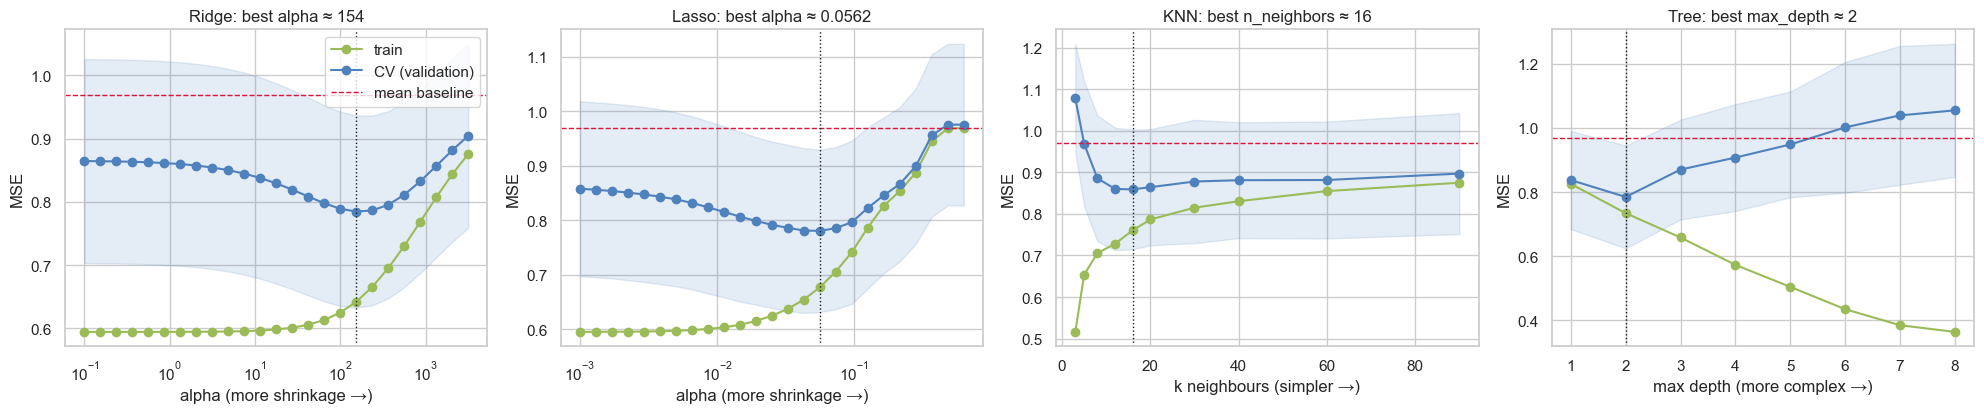

In [170]:
vc_cv = RepeatedKFold(n_splits=5, n_repeats=2, random_state=SEED)
specs = [("Ridge", "m__alpha", np.logspace(-1, 3.5, 25), "alpha (more shrinkage →)", True),
         ("Lasso", "m__alpha", np.logspace(-3, -0.2, 25), "alpha (more shrinkage →)", True),
         ("KNN", "m__n_neighbors", np.array([3, 5, 8, 12, 16, 20, 30, 40, 60, 90]), "k neighbours (simpler →)", False),
         ("Tree", "m__max_depth", np.arange(1, 9), "max depth (more complex →)", False)]
fig, axes = plt.subplots(1, 4, figsize=(20, 4.3))
for ax, (name, par, rng, xl, logx) in zip(axes, specs):
    model, _ = MODELS[name]
    base = pipe(model)
    if name == "Tree": base.set_params(m__min_samples_leaf=5)
    if name == "KNN": base.set_params(m__weights="uniform")
    tr, va = validation_curve(base, X_raw, y, param_name=par, param_range=rng, cv=vc_cv,
                              scoring="neg_mean_squared_error", n_jobs=-1)
    tr, va = -tr, -va
    ax.plot(rng, tr.mean(1), "o-", label="train", color="#9bbb59")
    ax.plot(rng, va.mean(1), "o-", label="CV (validation)", color="#4f81bd")
    ax.fill_between(rng, va.mean(1) - va.std(1), va.mean(1) + va.std(1), alpha=.15, color="#4f81bd")
    ax.axhline(y.var(), color="crimson", ls="--", lw=1, label="mean baseline")
    b = va.mean(1).argmin(); ax.axvline(rng[b], color="k", ls=":", lw=1)
    if logx: ax.set_xscale("log")
    ax.set_title(f"{name}: best {par.split('__')[1]} ≈ {rng[b]:.3g}"); ax.set_xlabel(xl); ax.set_ylabel("MSE")
axes[0].legend()
plt.tight_layout(); plt.show()

### 4c. Lasso coefficient path and the final Ridge / Lasso coefficients

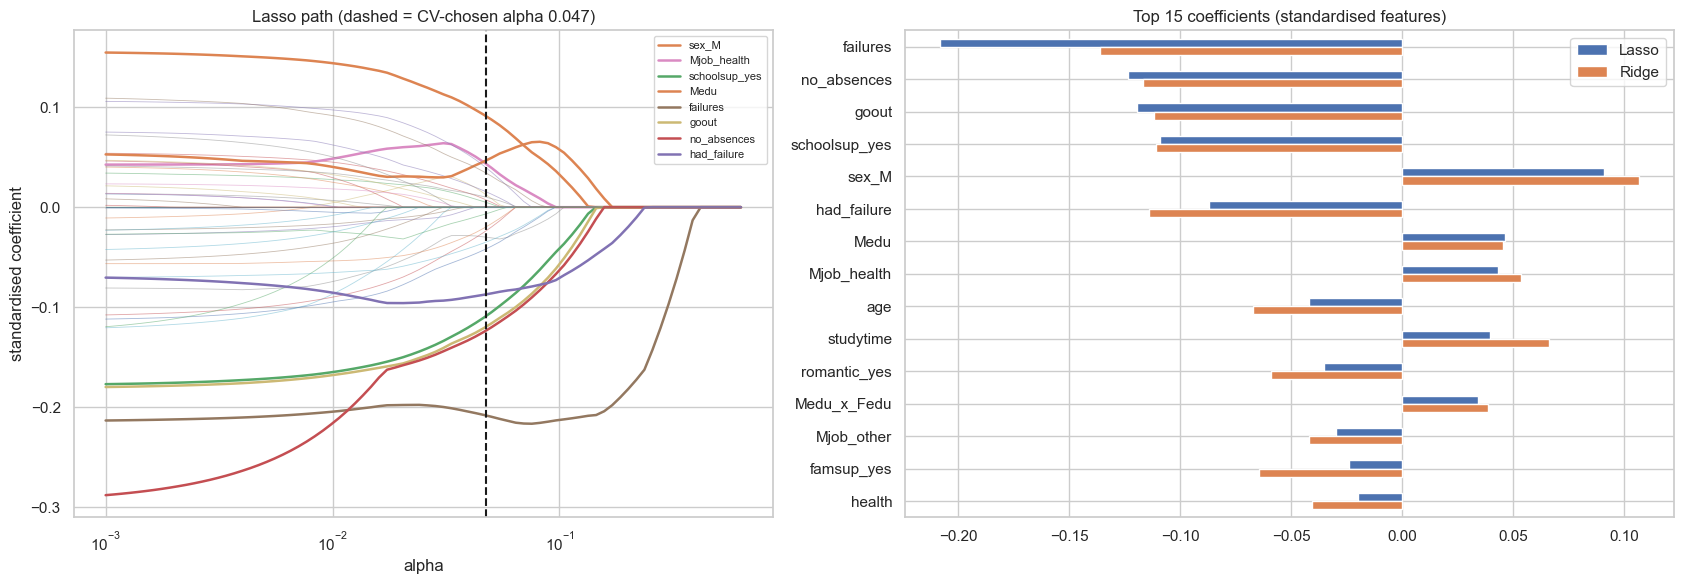

Lasso keeps 21 of 46 features


In [171]:
Xt = make_pre().fit_transform(X_raw)
alphas_path, coefs, _ = lasso_path(Xt, y, alphas=np.logspace(-3, -0.2, 80))

a_lasso = fitted["Lasso"].best_params_["m__alpha"]
lasso_coef = pd.Series(fitted["Lasso"].best_estimator_.named_steps["m"].coef_, index=feat_names)
ridge_coef = pd.Series(fitted["Ridge"].best_estimator_.named_steps["m"].coef_, index=feat_names)
top = lasso_coef.abs().sort_values(ascending=False).index[:8]

fig, ax = plt.subplots(1, 2, figsize=(17, 6), gridspec_kw=dict(width_ratios=[1, 1.1]))
for j, f in enumerate(feat_names):
    hi = f in top
    ax[0].plot(alphas_path, coefs[j], lw=1.8 if hi else .6, alpha=1 if hi else .5, label=f if hi else None)
ax[0].set_xscale("log"); ax[0].axvline(a_lasso, color="k", ls="--"); ax[0].set_xlabel("alpha"); ax[0].set_ylabel("standardised coefficient")
ax[0].set_title(f"Lasso path (dashed = CV-chosen alpha {a_lasso:.3f})"); ax[0].legend(fontsize=8)

sel = (lasso_coef.abs().sort_values(ascending=False).index[:15])
cdf = pd.DataFrame({"Lasso": lasso_coef[sel], "Ridge": ridge_coef[sel]})
cdf.plot.barh(ax=ax[1]); ax[1].invert_yaxis(); ax[1].set_title("Top 15 coefficients (standardised features)")
plt.tight_layout(); plt.show()
print(f"Lasso keeps {int((lasso_coef != 0).sum())} of {len(lasso_coef)} features")

## 5. Final model and predictions for `test.rds`

The model with the lowest nested-CV MSE is refit on **all** 316 training rows (with its hyper-parameters re-tuned by repeated CV) and used to predict the 79 test students.

Selected model: Random Forest
Hyper-parameters: {'m__max_features': 0.4, 'm__min_samples_leaf': 3}
Expected test MSE (nested CV): 0.7479,  mean-baseline MSE 0.9746

Predictions:
 [ 0.46965787  0.02679961  0.40593161 -0.02592224 -0.02858495  0.78123788
  0.55582085  0.46931052  0.85983375  0.54648045 -0.17395515  0.23332239
  0.24376888 -0.37219257  0.32290614  0.44778047  0.34885026 -0.45777546
  0.69854468 -0.088396    0.57327841  0.29775615  0.18745002  0.03227212
  0.22959493 -0.44732019  0.53108352  0.19260261 -0.57064775  0.54300373
  0.09617412  0.07953646  0.59968667  0.05431695 -0.48141004 -0.61312591
 -0.08800235  0.08231622  0.06947129  0.11045631  0.22386517  0.66830293
 -0.03190463 -0.12022981 -0.48588358 -0.39160217 -0.3661755  -0.22479746
  0.39637135  0.36011773  0.41183857 -0.86177032  0.05894035  0.3764311
  0.75869798 -0.11634561  0.21651908  0.40909516  0.00797669 -0.25753913
 -0.29991513  0.11905077  0.41988207  0.17083339 -0.23694056  0.21344155
  0.38414132 -0.324

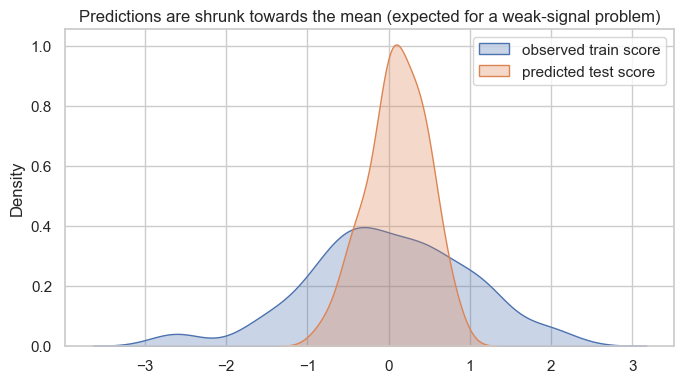

In [172]:
best_name="Random Forest"
final = fitted[best_name]
print("Selected model:", best_name)
print("Hyper-parameters:", final.best_params_)
print(f"Expected test MSE (nested CV): {res.loc[best_name, 'CV_MSE']:.4f},  "
      f"mean-baseline MSE {res.loc[BASE, 'CV_MSE']:.4f}")

pred = final.predict(test)
assert pred.shape == (79,) and np.isfinite(pred).all()
print("\nPredictions:\n", pred)
print("\nPrediction summary:", pd.Series(pred).describe().round(3).to_dict())

fig, ax = plt.subplots(figsize=(7, 4))
sns.kdeplot(y, ax=ax, label="observed train score", fill=True, alpha=.3)
sns.kdeplot(pred, ax=ax, label="predicted test score", fill=True, alpha=.3)
ax.set_title("Predictions are shrunk towards the mean (expected for a weak-signal problem)"); ax.legend()
plt.tight_layout(); plt.show()

Save `predictions.rds` as a plain numeric vector (written with R's `saveRDS`, so `readRDS("predictions.rds")` returns a numeric vector of length 79).

In [173]:
pd.Series(pred).to_csv("_pred_tmp.csv", index=False, header=False, float_format="%.10f")
rscript = shutil.which("Rscript") or (sorted(glob.glob(r"C:\Program Files\R\R-*\bin\Rscript.exe")) or [None])[-1]
print("Rscript:", rscript)
subprocess.run([rscript, "-e",
                "x <- scan('_pred_tmp.csv', quiet=TRUE); saveRDS(as.numeric(x), 'predictions.rds'); "
                "y <- readRDS('predictions.rds'); cat('class:', class(y), ' length:', length(y), '\\n'); print(summary(y))"],
               check=True)
import os; os.remove("_pred_tmp.csv")

Rscript: /usr/local/bin/Rscript
class: numeric  length: 79 
    Min.  1st Qu.   Median     Mean  3rd Qu.     Max. 
-0.86177 -0.11029  0.09617  0.10184  0.39026  0.85983 



## 6. Summary of findings

* **Signal is weak.** The best models reach a CV R² of only ~0.22, so the expected test MSE is ~0.75 versus 0.97 for predicting the mean. This is consistent across the nested CV and the independent hold-out check.
* **Ranking (nested CV MSE):** Random Forest 0.749 < Gradient Boosting 0.757 < Ridge 0.785 ≈ Elastic Net 0.786 ≈ Lasso 0.787 ≈ Tree 0.791 < OLS 0.857 < KNN 0.870 < mean 0.975.
  The top models are close relative to the fold-to-fold spread (sd ≈ 0.16), so Random Forest is ahead but not by a wide margin. The regularised linear models are almost as good and more interpretable.
* **Regularisation matters.** Plain OLS (46 features, n = 316) over-fits: in-sample R² 0.35 but CV R² 0.10 (CV-adjusted R² < 0). Ridge/Lasso lift CV R² to ~0.18, and Lasso keeps only 21 of 46 features.
* **Feature engineering helped:** log(absences), the no-absence flag, a failure flag and Medu × Fedu lowered the CV MSE by about 3–4 % for Ridge and Lasso, and by about 1 % for Random Forest.
* **Over-fitting:** KNN (train RMSE ≈ 0.38 vs CV 0.93) and, to a lesser extent, Random Forest (0.63 vs 0.87) have large train/CV gaps. The train error is not a valid guide for those, which is why the selection uses the nested-CV error. Random Forest still has the lowest out-of-sample error.
* **Main drivers:** past `failures`, parents' education, `age`, `goout`, `higher`, `schoolsup`. The fitted curves in section 5b show the models track the observed means for these features.
